In [118]:
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import colorir as cl
from analyses.parse import parse_cells_multiple

In [119]:
sim_paths = {}
for path in Path("../runs/speed/").iterdir():
    sim_type = path.name
    for replica_path in path.iterdir():
        replica = int(replica_path.name)
        sim_paths[(sim_type, replica)] = replica_path

In [120]:
sims = parse_cells_multiple(sim_paths.values(), 30)

In [121]:
sim_ids = list(sim_paths.keys())
for i in range(len(sims)):
    sims[i] = sims[i].with_columns(
        sim_type=pl.lit(sim_ids[i][0]), 
        sim_replica=sim_ids[i][1]
    )
celldf = pl.concat(sims)

In [122]:
celldf = celldf.with_columns(displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5)

In [123]:
grouppers = ["sim_type", "sim_replica", "time"]
displdf = celldf.group_by(grouppers).agg(
    cluster_x=pl.col("center_x").mean(),
    cluster_y=pl.col("center_y").mean(),
    mean_displ=pl.col("displ").mean(),
    med_displ=pl.col("displ").median()
).sort(grouppers)
displdf

sim_type,sim_replica,time,cluster_x,cluster_y,mean_displ,med_displ
str,i32,i32,f32,f32,f32,f32
"""energy-0""",0,0,433.299988,433.299988,614.067688,615.056519
"""energy-0""",0,100000,413.310394,413.587372,586.231628,585.79425
"""energy-0""",0,200000,409.151398,407.324493,578.607239,578.171692
"""energy-0""",0,300000,409.664856,405.502808,577.719238,575.558044
"""energy-0""",0,400000,408.547577,402.053589,574.657471,575.424072
…,…,…,…,…,…,…
"""energy-8""",4,14500000,92.05336,84.529884,137.727005,124.621986
"""energy-8""",4,14600000,92.330116,78.053825,131.215103,125.427643
"""energy-8""",4,14700000,94.257248,82.018929,135.651489,125.530319


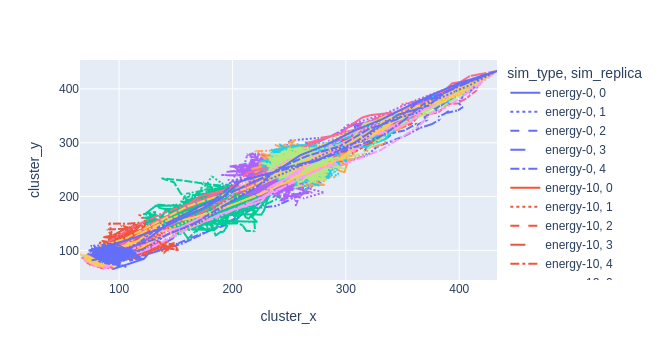

In [124]:
# Cluster trajectories
px.line(
    displdf,
    x="cluster_x",
    y="cluster_y",
    color="sim_type",
    line_dash="sim_replica"
)

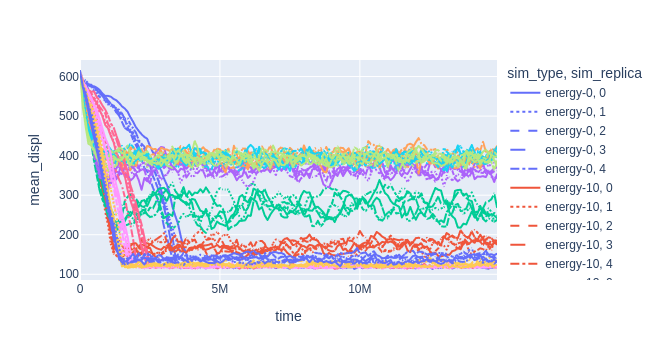

In [125]:
px.line(
    displdf,
    x="time",
    y="mean_displ",
    color="sim_type",
    line_dash="sim_replica"
)

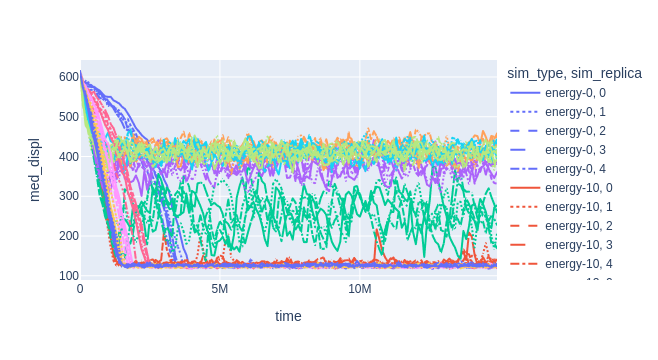

In [126]:
px.line(
    displdf,
    x="time",
    y="med_displ",
    color="sim_type",
    line_dash="sim_replica"
)

In [127]:
banddf = displdf.group_by(["sim_type", "time"]).agg(
    med_med=pl.col("med_displ").median(),
    med_mean=pl.col("med_displ").mean(),
    med_min=pl.col("med_displ").min(),
    med_max=pl.col("med_displ").max(),
    mean_mean=pl.col("mean_displ").mean(),
    mean_med=pl.col("mean_displ").median(),
    mean_min=pl.col("mean_displ").min(),
    mean_max=pl.col("mean_displ").max(),
).sort(["sim_type", "time"])
banddf

sim_type,time,med_med,med_mean,med_min,med_max,mean_mean,mean_med,mean_min,mean_max
str,i32,f32,f32,f32,f32,f32,f32,f32,f32
"""energy-0""",0,615.056519,615.056519,615.056519,615.056519,614.06781,614.067871,614.067688,614.067932
"""energy-0""",100000,591.632568,590.016235,585.79425,592.179565,589.875183,591.550842,586.231628,592.394531
"""energy-0""",200000,581.323669,583.141296,578.171692,590.399719,583.046875,580.788147,578.607239,590.307861
"""energy-0""",300000,581.497314,578.377258,565.535706,586.882507,577.988525,579.887512,568.273499,582.176147
"""energy-0""",400000,575.424072,574.763062,567.746216,579.748901,574.706665,574.657471,569.408569,579.272644
…,…,…,…,…,…,…,…,…,…
"""energy-8""",14500000,127.701149,127.194191,124.621986,129.948029,144.003204,139.600906,131.958923,159.308716
"""energy-8""",14600000,125.336456,125.06752,124.434364,125.427643,138.602463,133.116943,131.215103,149.678085
"""energy-8""",14700000,123.690567,123.740402,121.609505,125.574509,139.535797,135.651489,132.738571,150.611618


/tmp/ipykernel_1624895/2279924122.py:3: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



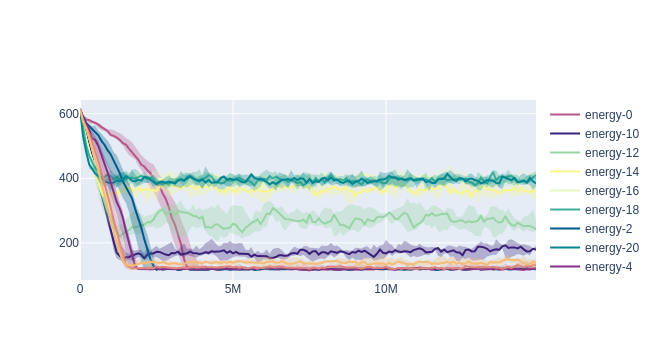

In [128]:
import random as rand

palette = cl.StackPalette.load("carnival").resize(banddf["sim_type"].n_unique())
colors = palette.colors
rand.shuffle(colors)
palette = cl.StackPalette(colors)
fig = go.Figure()
for i, (sim_type, group) in enumerate(banddf.group_by("sim_type")):
    fig.add_trace(go.Scatter(
        x=group["time"],
        y=group["mean_med"],
        line_color=palette[i],
        name=sim_type[0]
    ))
    fig.add_trace(go.Scatter(
        x=pl.concat([group["time"], group["time"][::-1]]),
        y=pl.concat([group["mean_min"], group["mean_max"][::-1]]),
        fill="toself",
        line_color="rgba(0, 0, 0, 0)",
        fillcolor=palette[i],
        opacity=0.3,
        showlegend=False
    ))
fig